# Unsupervised Learning

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/06-Unsupervised-Learning/ml_map.png'>

**Supervised Learning**

- Dataset = $X$, $y$

- $X$ = feature matrix $(n,p)$

- $y$ = targets vector $(n,1)$


> Find $h_{\beta}(X)$ as close to $y$ as possible

__Unsupervised Algorithms__ 
> find patterns in $X$, __without supervision from a target  $y$__

Unsupervised Learning helps us **reduce dimensions**
- Feature Engineering/less features (saves time)
- Compress (saves space)

It also allows us to **cluster data** (= group data points based on similarities)
- Understand data (explore, visualize, etc.)
- Find anomalies/outliers?
- Recommendations
- Semi-supervised classifications

## Plan

1. Principal Component Analysis (PCA)
2. Clustering with K-Means Algorithm

## 1. Principal Component Analysis (PCA)

- Squashes our high-dimensional dataset down into a lower dimension

- Aims to find the best linear combination of features (= columns) that best represents the underlying structure of the data

#### Remember Linear Regression Variants?

*Polynomial*  
$ \hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 X_1^2 $

*Log transformation*  
$ \hat{y} = \beta_0 + \beta_1 \log(X_1) $

*Linear combination of features (while avoiding multicolinearity)*  
$ \hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 (X_2 + X_3) $

👉 PCA = finding the **best linear combination** of features

&nbsp;  
$ \color{red}{Z_1} = a_{11} X_1 + a_{12} X_2 + a_{13} X_3 \\
\color{red}{Z_2} = a_{21} X_1 + a_{22} X_2 + a_{23} X_3 \\
\color{red}{Z_3} = a_{31} X_1 + a_{32} X_2 + a_{33} X_3$
&nbsp;  

- Canceling **<u>ALL</u>** multicolinearity
- **Ranking** the newly created PCs $Z$ from most to least important

$\color{red}{Z_i}$ is a so-called <font color=red>Principal Component (PC)</font>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/pca-transform-1.png'>

PCA is essentially a projection of the data that is
- oriented towards specific directions, defined by the **Principal Components**
- orthonormal to each other (0 multicolinearity)
- ranked by decreasing "explaining power"  
  (measured by the variance of our data when projected onto this PC)


#### Intuition

If we had to keep **only one direction** to describe our data, this direction should

- **preserve** most of the **variance** in the data when projected onto it (see spread of red dots)
- minimize "reconstruction errors" (see red lines)

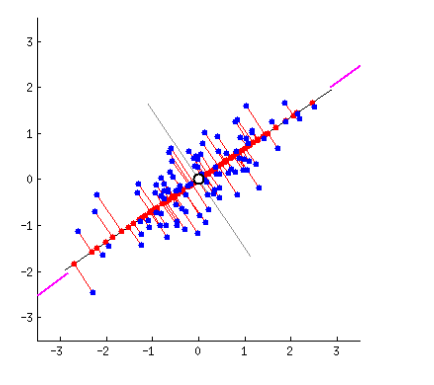

👉 [stats-exchange story](https://stats.stackexchange.com/a/140579/286995)

<img src='https://i.stack.imgur.com/Q7HIP.gif'>

**3 components**
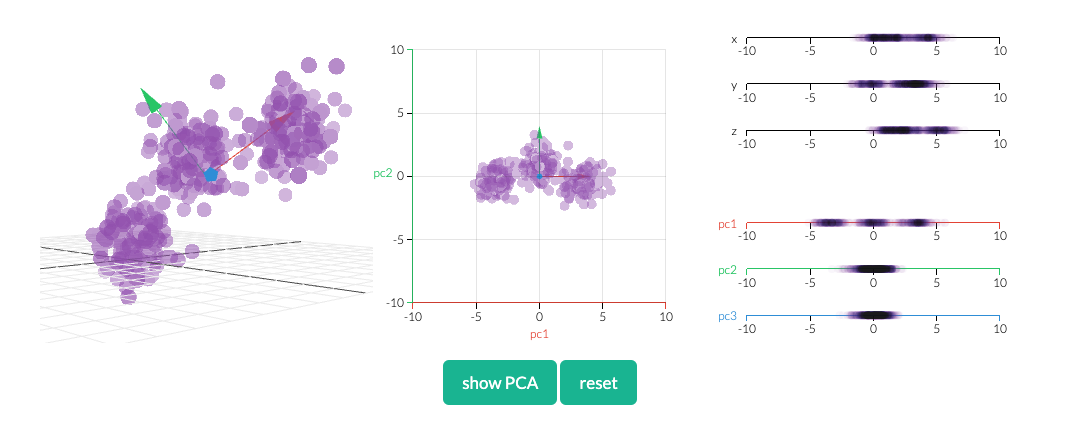
👉 [interactive visuals](http://setosa.io/ev/principal-component-analysis/)  

👉 **PCA helps to reduce dimensions!**

$ (X_1, X_2, X_3) \sim (Z_1, Z_2) $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/lower_dimension_representation.png' width = 800>

📚 [Hands-On Machine Learning](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

### 1.2 Let's Code an Example (with a Wine Dataset)

In [60]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [61]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
wine_features = X.columns

#⚠️ Data must be centered around its mean before applying PCA ⚠️
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

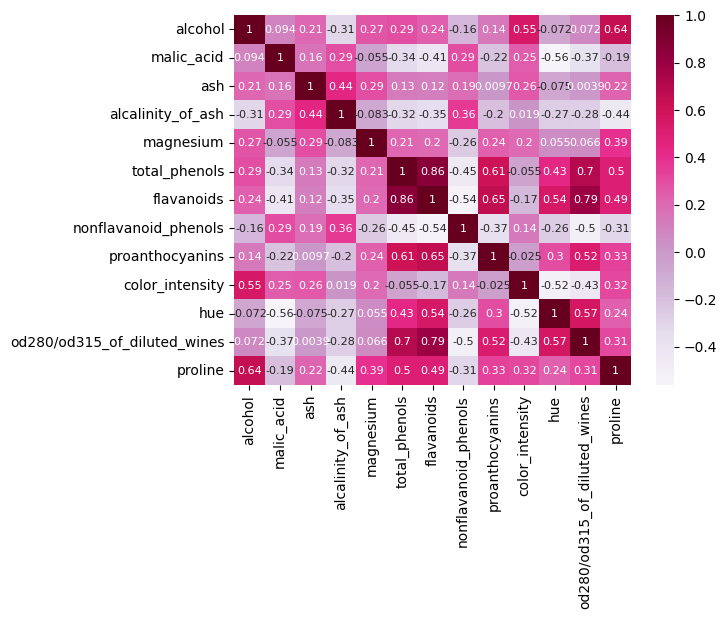

In [62]:
sns.heatmap(X.corr(),
            annot = True,
            annot_kws={"size":8},
            cmap = "PuRd")

plt.show();

#### a) Compute the Principal Components

In [63]:
from sklearn.decomposition import PCA

# Instantiate the PCA
pca = PCA().set_output(transform="pandas")

# Find the components
pca.fit(X_scaled)

PCA()

In [64]:
# Access our 13 PCs & Print PCs as COLUMNS
components = pd.DataFrame(pca.components_ ).T
components.columns = [f'PC{i}' for i in range(0, 13)]
components.index = X.columns
components

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539,-0.056396,0.396139,-0.508619,0.211605,-0.225917,-0.266286,0.014970
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,-0.309080,0.076486,0.121696,0.025964
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475,-0.149171,-0.170260,0.307694,-0.027125,-0.498691,-0.049622,-0.141218
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825,-0.286969,0.427970,-0.200449,0.052799,0.479314,-0.055743,0.091683
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144,0.322883,-0.156361,-0.271403,0.067870,0.071289,0.062220,0.056774
total_phenols,0.394661,0.065040,0.146179,0.198068,-0.149318,-0.084122,-0.027925,-0.405934,-0.286035,-0.320131,0.304341,-0.303882,-0.463908
flavanoids,0.422934,-0.003360,0.150682,0.152295,-0.109026,-0.018920,-0.060685,-0.187245,-0.049578,-0.163151,-0.025694,-0.042899,0.832257
nonflavanoid_phenols,-0.298533,0.028779,0.170368,-0.203301,-0.500703,-0.258594,0.595447,-0.233285,-0.195501,0.215535,0.116896,0.042352,0.114040
proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860,-0.533795,0.372139,0.368227,0.209145,0.134184,-0.237363,-0.095553,-0.116917
color_intensity,-0.088617,0.529996,-0.137306,0.065926,-0.076437,-0.418644,-0.227712,-0.033797,-0.056218,-0.290775,0.031839,0.604222,-0.011993


&nbsp;   
☝️ Each PC is a **linear combination of initial wine features**

#### b) *Project* our dataset into this new space of PCs

In [65]:
X_proj = pca.transform(X_scaled)
X_proj

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810,-0.066239
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238,0.003637
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584,0.021717
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020,-0.369484
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664,-0.079364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527,-0.574164,1.108788,0.958416,0.146097,0.022498,-0.304117,0.139228,0.170786,-0.114427
174,-2.601956,1.757229,0.207581,0.349496,0.255063,0.026465,0.146894,0.552427,0.097969,-0.206061,0.258198,-0.279431,-0.187371
175,-2.677839,2.760899,-0.940942,0.312035,1.271355,-0.273068,0.679235,-0.047024,-0.001222,-0.247997,0.512492,0.698766,0.072078
176,-2.387017,2.297347,-0.550696,-0.688285,0.813955,-1.178783,0.633975,-0.390829,-0.057448,0.491490,0.299822,0.339821,-0.021866


&nbsp;  
☝️ 178 wine bottles, each expressed as a linear combination of 13 Principal Components

✅ As expected, the PCA reduces multicolinearity to the absolute minimum (0)!

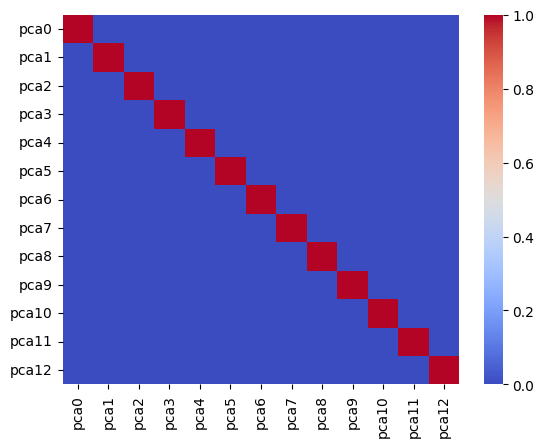

In [66]:
sns.heatmap(X_proj.corr(), cmap='coolwarm');

✅ Our wine dataset is also easier to observe in this new space

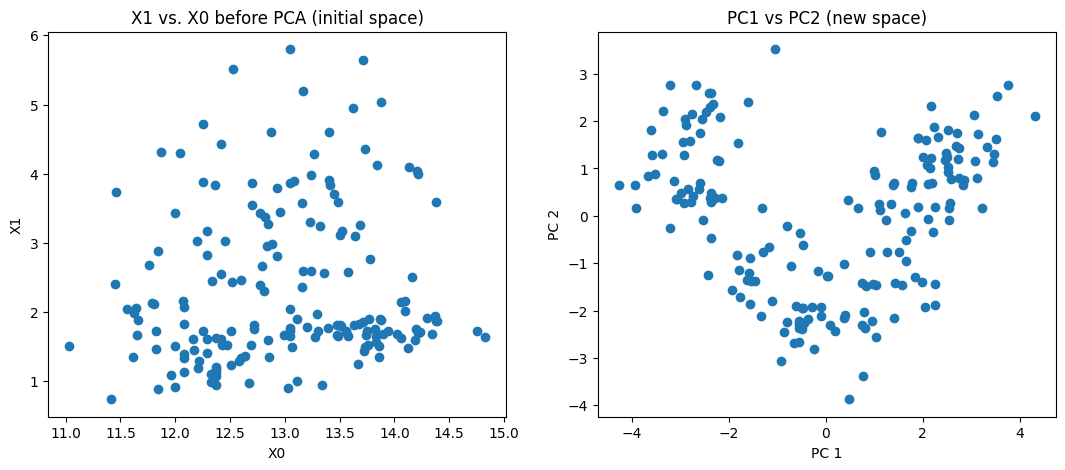

In [67]:
# 2D-slice

plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.title('X1 vs. X0 before PCA (initial space)'); plt.xlabel('X0'); plt.ylabel('X1')
plt.scatter(X.iloc[:,0], X.iloc[:,1])

plt.subplot(1,2,2)
plt.title('PC1 vs PC2 (new space)'); plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1]);

Adding true labels makes it even clearer
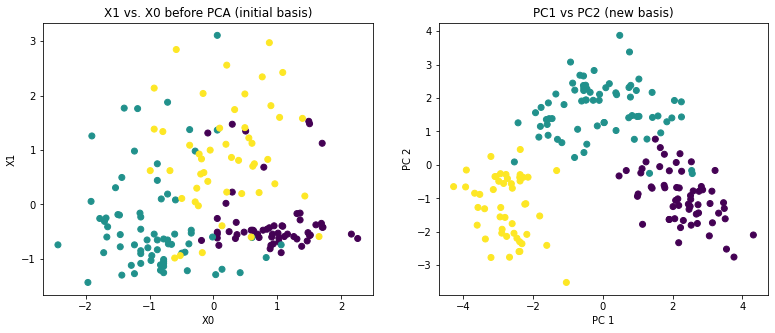

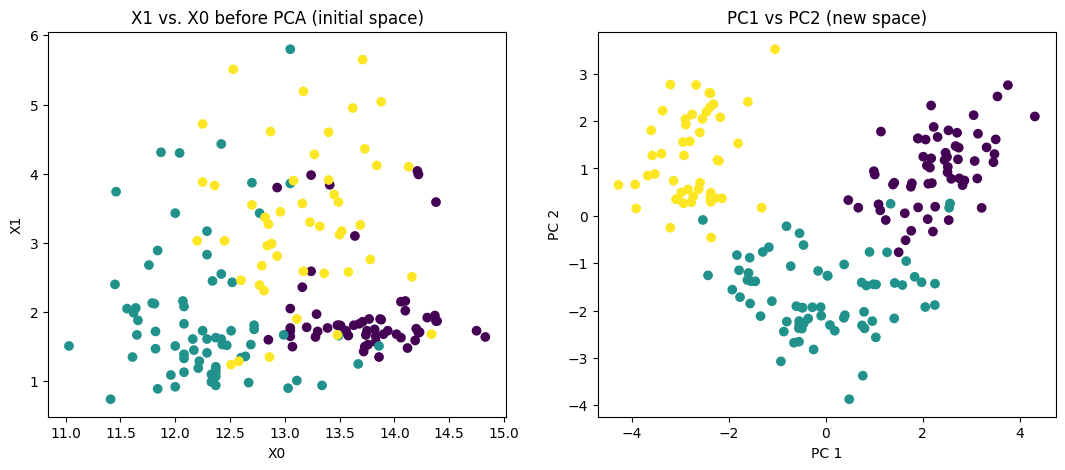

In [68]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.title('X1 vs. X0 before PCA (initial space)'); plt.xlabel('X0'); plt.ylabel('X1')
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y)

plt.subplot(1,2,2)
plt.title('PC1 vs PC2 (new space)'); plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1], c=y);

#### 💡 "Projecting" data onto a new space is a simple matrix multiplication

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/pca-transform-3.png">

In [69]:
# Computational proof
W = pca.components_.T
print("Shape of W: ", W.shape)
print("Shape of X", X.shape)

Shape of W:  (13, 13)
Shape of X (178, 13)


In [70]:
np.allclose(
    pca.transform(X),
    np.dot(X,W)
)

True

### 1.3 How are Principal Components Computed (Mathematically)?

This is the hard part

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/pca-transform-2.png'>

We can do it with `NumPy`

- `np.linalg.eig(M)` computes the `eig_vals` and `eig_vecs` of M
- Covariance Matrix = $X^T X$ of shape `(p,p)` (if features are centered)

❗️ `eig()` decomposition can take very long


ℹ️ <a href="https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors" target="_blank">Eigenvalues and Eigenvectors</a>

In [71]:
# Compute PCs
eig_vals, eig_vecs = np.linalg.eig(np.dot(X.T,X))

In [72]:
# Show all 13 principal components (unranked)
W = pd.DataFrame(eig_vecs,
                 index=wine_features,
                 columns=[f'PC{i}' for i in range(1, 14)])
W

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
alcohol,0.014963,-0.114188,-0.266490,-0.059866,-0.799055,-0.255171,0.421559,-0.072748,0.113826,0.050537,-0.064737,0.075782,0.009284
malic_acid,0.002545,-0.028120,-0.112360,-0.170168,-0.043545,-0.746916,-0.624512,0.041798,0.012294,0.012922,-0.014861,-0.073565,0.011342
ash,0.002708,-0.022174,-0.064566,0.006662,-0.040004,0.000520,-0.015522,0.149962,0.069551,0.072214,0.945530,0.187848,0.177739
alcalinity_of_ash,0.021383,-0.228260,-0.905891,0.181843,0.279870,0.107962,-0.023165,-0.001923,0.003957,0.000774,-0.056440,-0.003175,-0.000681
magnesium,0.115578,-0.957835,0.258251,-0.007393,0.048442,0.002666,-0.007045,0.004836,-0.001862,0.000400,-0.003381,-0.000285,-0.002115
total_phenols,0.002744,-0.015067,-0.018478,0.096001,-0.240818,0.216595,-0.266395,0.165060,0.247455,-0.851427,-0.003368,0.007698,0.029285
flavanoids,0.002528,-0.008077,0.011754,0.197440,-0.314735,0.389761,-0.464216,0.262538,0.376099,0.513766,-0.118852,0.012984,-0.075574
nonflavanoid_phenols,0.000391,-0.004272,-0.018791,-0.010816,-0.004353,-0.028837,0.036422,-0.017437,0.034522,-0.046908,0.215565,-0.162344,-0.959591
proanthocyanins,0.001890,-0.011610,-0.006072,0.061733,-0.146244,0.187033,-0.296788,-0.912749,-0.037624,0.001741,0.124877,0.031514,0.021122
color_intensity,0.006070,-0.034076,-0.151711,-0.912651,-0.062308,0.332165,-0.106465,0.054642,-0.103104,0.016680,-0.000812,-0.058266,0.003829


### 1.4 PCs are ranked by order of importance

> $PCs$ are ranked by share of **explained variance** $\frac{Var(PC_i)}{Var(X)}$

❗️ Remember: information comes in the form of variation  
❗️ PC with most variance is the most important one

In [73]:
# Let's compute it
X_proj.std()**2 / ((X.std()**2).sum())

pca0     0.000048
pca1     0.000025
pca2     0.000015
pca3     0.000009
pca4     0.000009
pca5     0.000006
pca6     0.000006
pca7     0.000004
pca8     0.000003
pca9     0.000003
pca10    0.000002
pca11    0.000002
pca12    0.000001
dtype: float64

☝️ scikit-learn `PCA` has indeed already ranked them

> 36% of the dataset’s variance lies along the first axis

In [74]:
# Sklearn provides it automatically
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

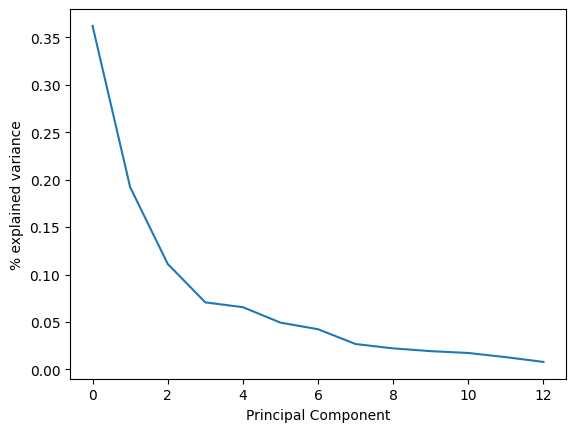

In [75]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Principal Component'); plt.ylabel('% explained variance');

> PCA redistributes the ratio among the new features in the **most unequal way**

### 1.5 PCA for Dimensionality Reduction

👉 Having computed all PCs, we can now keep only the `k` most important ones!

&nbsp;  
❓  Why would we want less features? Because it means we can
- compress data  
- reduce model complexity & fit time  
- reduce overfitting

#### How to choose `k`? 

It's a **trade-off** between compression and performance

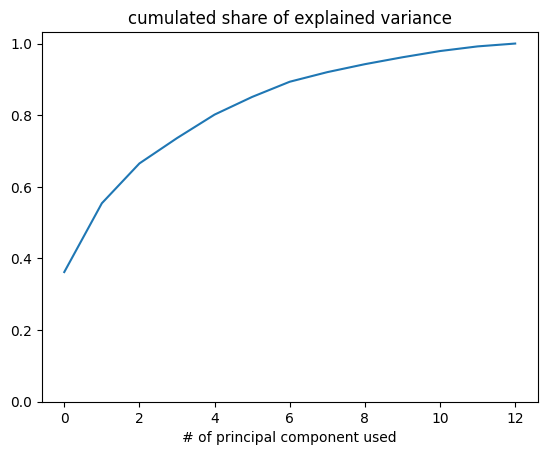

In [76]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylim(ymin=0)
plt.title('cumulated share of explained variance')
plt.xlabel('# of principal component used');

#### The Elbow Method

Look for the *inflection point* in the explained variance chart

Here, `k=3` looks promising

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/scree_explained.png'>

#### ✏️ Test Model Performance (with `k=3` Dimensions)

In [77]:
# Fit a PCA with only 3 components
pca3 = PCA(n_components=3).fit(X)

# Project your data into 3 dimensions
X_proj3 = pd.DataFrame(pca3.fit_transform(X), columns=['PC1', 'PC2', 'PC3'])

# We have "compressed" our dataset in 3D
X_proj3

,PC1,PC2,PC3
0,318.562979,21.492131,-3.130735
1,303.097420,-5.364718,-6.822835
2,438.061133,-6.537309,1.113223
3,733.240139,0.192729,0.917257
4,-11.571428,18.489995,0.554422
...,...,...,...
173,-6.980211,-4.541137,2.474707
174,3.131605,2.335191,4.309931
175,88.458074,18.776285,2.237577
176,93.456242,18.670819,1.788392


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print("accuracy 3 PCs")
print(cross_val_score(LogisticRegression(max_iter=300), X_proj3, y, cv=5).mean())

print("\naccuracy all 13 initial features")
print(cross_val_score(LogisticRegression(max_iter=300), X_scaled, y, cv=5).mean())

accuracy 3 PCs
0.7925396825396824

accuracy all 13 initial features
0.9888888888888889


#### Decompress
❓ Can you **perfectly** reconstruct `X` from `X_proj3`?
 
- Not if you kept `k < 13` dimensions; information has been lost
- We can *approximate* `X` by reconstructing it with `inverse_transform()` 

In [79]:
X_reconstructed = pca3.inverse_transform(X_proj3)
X_reconstructed.shape

(178, 13)

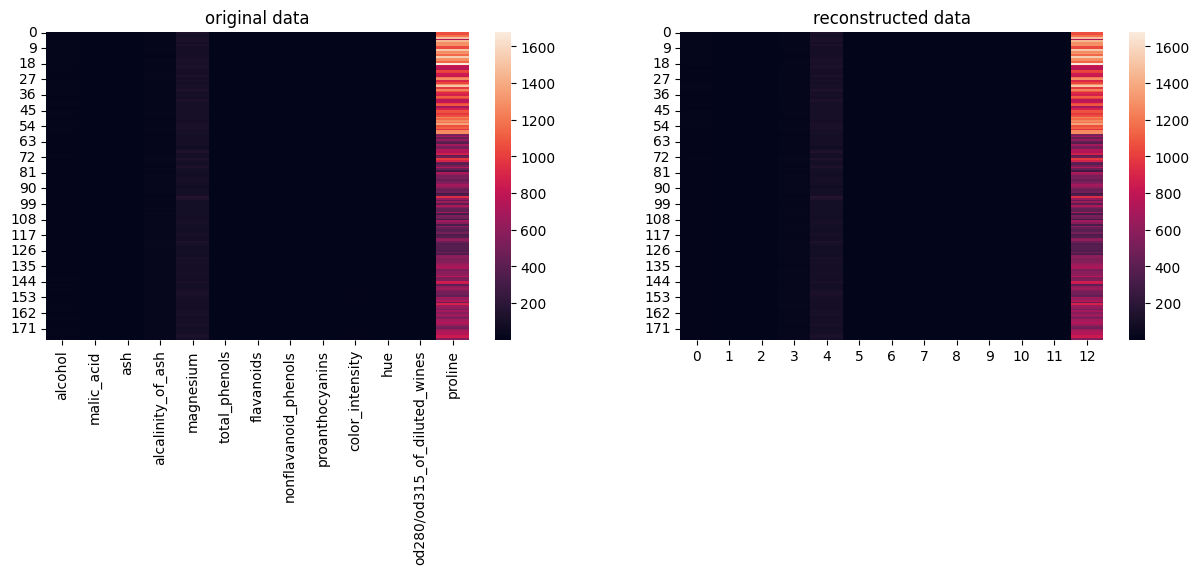

In [80]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.heatmap(X)
plt.title("original data")
plt.subplot(1,2,2)
plt.title("reconstructed data")
sns.heatmap(X_reconstructed);

### 1.6 Limitations of PCA


Watch out for **manifolds** 👀

A manifold is an N-dimensional shape that can be bent and twisted into a higher dimensional shape 🍥

Below we can see our data distribution before and after PCA has been applied

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/manifold.png' width = 800>

📚 [Hands-On Machine Learning](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

Other dimensionality reduction techniques:
* **t-Distributed Stochastic Neighbor Embedding (t-SNE)** — Aims to reduce dimensionality while keeping similar observations close together and dissimilar ones apart. This is a great technique for visualizing clusters of higher dimensions
* **Kernel PCA** — Captures non-linear patterns (similar principle to SVM kernels)


## Summary
* We use PCA to deal with high-dimensional datasets; some pros are:  
    * Better visualization of the data
    * Reduction of the effects of the curse of dimensionality 
    * Reduction of file size 
* PCA compresses the datasets into a lower-dimensional state by projecting observations onto a new space
* More variation, more information, easier to distinguish between observations
* When we use PCA we lose data interpretability

# 2. Clustering (Intro Through K-Means)

> The process of organizing data points into groups whose members are similar in some way

Find **categories** (classes, segments) of **unlabelled** data rather than just trying to reduce dimensionality

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/06-Unsupervised-Learning/labelling-clusters.png' width=500>

👉 Works better on data that is already clustered, geometrically speaking  
👉 Use PCA for dimensionality reduction beforehand Euclidean distances work better in lower dimensions)!

## 2.1 K-Means Explained

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KMeans.png' width = 600>


1. Choose the number of clusters `K` to look for  
2. Initialize `K` **centroids** at random
3. Compute the **mean square distance** between each data point and each centroid
4. Assign each data point to the closest centroid (a cluster is formed)
5. Compute the mean $\mu_j$ of each cluster, the result of which becomes your new centroid

One epoch is done, repeat from step 3!

<img src="https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif">

**In practice**
- K-means is usually run a few times with different random initializations
- We can use a random mini-batch at each epoch instead of the full dataset
- The algorithm is quite fast

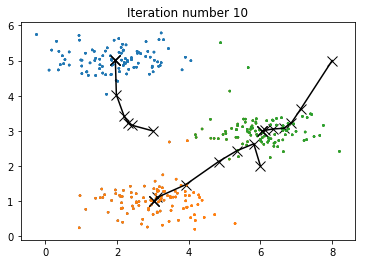

## 2.2 Implementation

#### In Scikit-learn

https://scikit-learn.org/stable/modules/clustering.html

Use 
- `scikit.clustering.KMeans` 
- `scikit.clustering.MiniBatchKMeans` — same but uses batch samples instead of the whole dataset, in order to go faster

#### 📝  Let's try to find `k = 3` clusters for our wine dataset
(suppose we don't know the true labels)

&nbsp;  
💡 First, let's place ourselves in the Principal Component space we had already computed

Although not mandatory, applying PCA first helps to separate data more easily!

In [81]:
X_proj

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810,-0.066239
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238,0.003637
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584,0.021717
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020,-0.369484
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664,-0.079364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527,-0.574164,1.108788,0.958416,0.146097,0.022498,-0.304117,0.139228,0.170786,-0.114427
174,-2.601956,1.757229,0.207581,0.349496,0.255063,0.026465,0.146894,0.552427,0.097969,-0.206061,0.258198,-0.279431,-0.187371
175,-2.677839,2.760899,-0.940942,0.312035,1.271355,-0.273068,0.679235,-0.047024,-0.001222,-0.247997,0.512492,0.698766,0.072078
176,-2.387017,2.297347,-0.550696,-0.688285,0.813955,-1.178783,0.633975,-0.390829,-0.057448,0.491490,0.299822,0.339821,-0.021866


In [82]:
from sklearn.cluster import KMeans

# Fit K-means
km = KMeans(n_clusters=3)
km.fit(X_proj)

KMeans(n_clusters=3)

In [83]:
# The 3 centroids' coordinates (expressed in the space of PCs)
km.cluster_centers_.shape

(3, 13)

In [84]:
# The 177 observations are classified automatically
km.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

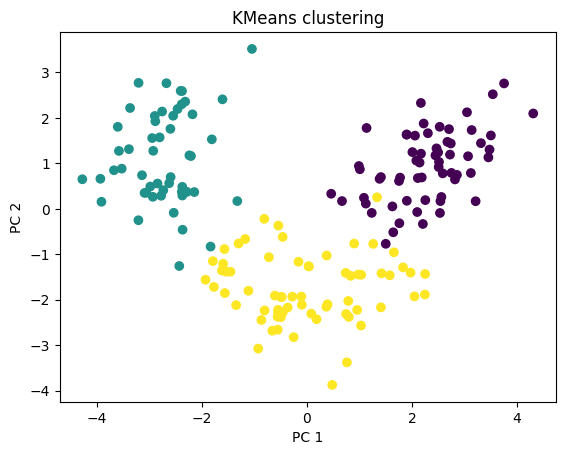

In [85]:
plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1], c=km.labels_)
plt.title('KMeans clustering'); plt.xlabel('PC 1'); plt.ylabel('PC 2');

💡 In our case, we *know* the true labels; let's measure performance.

🧨🧨🧨 Let's also visualize the centroids!!!

In [86]:
my_centroids = pd.DataFrame(km.cluster_centers_)
my_centroids.columns = X_proj.columns
my_centroids

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12
0,2.291601,0.943181,-0.086076,-0.141638,-0.141001,0.234992,0.062807,0.003787,0.057930,0.080032,0.019265,-0.006355,0.026311
1,-2.720036,1.125651,-0.239093,0.062457,0.073676,-0.099925,-0.060383,0.007388,-0.020027,-0.061468,-0.008116,-0.003455,-0.050551
2,-0.016149,-1.741549,0.264309,0.082646,0.073388,-0.139975,-0.011389,-0.009209,-0.038066,-0.026470,-0.011534,0.008543,0.014744


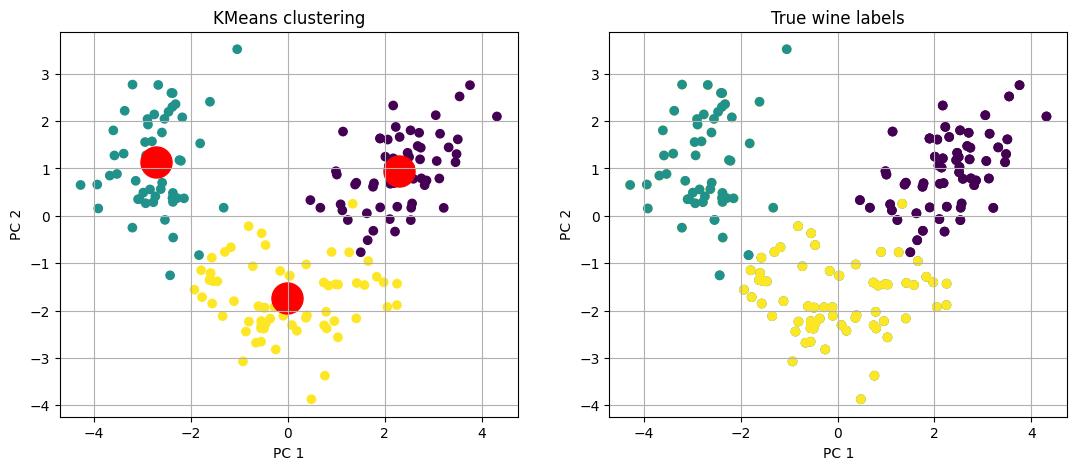

In [87]:
# Visualization
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1], c=km.labels_)
plt.scatter(my_centroids.iloc[:,0], my_centroids.iloc[:,1], c="r", s=500)
plt.title('KMeans clustering'); plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.grid()

plt.subplot(1,2,2)
plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1], c=y)
plt.title('True wine labels'); plt.xlabel('PC 1'); plt.ylabel('PC 2');plt.scatter(X_proj.iloc[:,0], X_proj.iloc[:,1],c = km.labels_)
plt.grid()

In [88]:
# Accuracy
from sklearn.metrics import accuracy_score

y_pred = pd.Series(km.labels_).map({0:0, 1:2, 2:1}) # WARNING: change this manually!
accuracy_score(y_pred, y)

0.9719101123595506

#### Predict?

We can use the unsupervised K-means algorithm to **predict** (classify) a new X

In [89]:
# Build DF with column names from X_proj and some random data
new_X = pd.DataFrame(data = np.random.random((1,13)), columns = X_proj.columns)

km.predict(new_X)

array([0], dtype=int32)

## 2.3 K-Means' Loss Function?

`km.fit(X)` finds parameters $\beta$ that minimize a loss 

- Each $\beta_j$ parameter is the **centroid** $\mu_j$ of its respective cluster $C_j$

- The loss function is called **inertia** $L(\mu)$ 

- = **sum** of **squared distance** between each observation and their **closest centroid**
- = sum of **within-cluster sum of squares** (WCSS)
- = variance
$$\text{inertia} = L(\mu) = \sum_{j=1}^{K}\sum_{x_i \in C_j}(||x_i - \mu_j||^2)$$

<img src="https://github.com/davydw/public-pictures/blob/main/data-illustrations/kmeans_inertia.png?raw=true">

### Choosing Hyperparameter K

- Choose `K` such that the inertia (`Kmeans().inertia_`) is minimized
- Use the **elbow method** here as well

Text(0.5, 0, 'k cluster number')

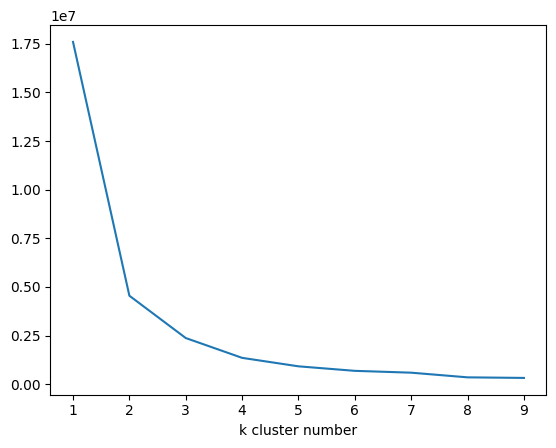

In [90]:
inertias = []
ks = range(1,10)

for k in ks:
    km_test = KMeans(n_clusters=k).fit(X)
    inertias.append(km_test.inertia_)

plt.plot(ks, inertias)
plt.xlabel('k cluster number')

### What can we use it for?

👉 Document classification (finding unlabeled categories or topics)

👉 Delivery store optimization (find the optimal number of launch locations)

👉 Customer segmentation (classify different types of customer based on their behavior)

https://dzone.com/articles/10-interesting-use-cases-for-the-k-means-algorithm

## 2.4 There are many other clustering approaches

https://scikit-learn.org/stable/modules/clustering.html

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png'>

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/06-Unsupervised-Learning/ml_map.png'>

## Bibliography

- [PCA explained to your grandmother](https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues) 1700 upvotes on StackExchange 💫
- 📄 [PCA for ML](https://towardsdatascience.com/using-principal-component-analysis-pca-for-machine-learning-b6e803f5bf1e)
- 📄 [KMeans explained](https://towardsdatascience.com/k-means-clustering-explain-it-to-me-like-im-10-e0badf10734a)


# 🚀 Your turn!